# GC10-DET - the detector, its own metric, and two operating points

**Arkon Manufacturing AI | Module: CV Object Detection | Department: Stamping**

Notebooks 01 and 02 established what the dataset holds, repaired three label
faults and built a split over coils rather than over sheets. This one fits the
module: a ten-class object detector over 2048 x 1000 photographs of steel strip,
which answers a question no other Arkon module answers. Casting says defective or
sound, NEU names a defect type, MVTec scores how unusual a part is, and all three
return one answer for a whole frame. This one returns a box.

Three things here are new to this project and each gets its own section.

**The metric had to be written.** Neither `torchmetrics` nor `pycocotools` is in
this environment and adding a dependency to compute one number is not worth it, so
section 4 implements VOC average precision and validates it on cases whose answer
can be worked out by hand. A metric nobody checked is a ruler nobody checked.

**There are two operating points, not one.** Every other module has a single
threshold. A detector needs one to decide what counts as a box at all, and this
module needs a second to decide how sure it is about the sheet, because the event
it publishes is about the sheet. Sections 8 and 9 choose them separately and say
what each one is for.

**There is no good class, and no sound sheet either.** Notebook 02 dropped the
eight sheets that carry no box because nobody certified them clean. So a sheet
with no detection is the module failing to find something, not the module saying
the steel is sound, and section 13 is where that distinction becomes the event
adapter's no-event rule.

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

# notebooks/ holds the shared helpers; this notebook sits two levels below it
_nb_root = Path('../..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import get_mlflow_uri, save_figure

print('arkon_utils loaded')

arkon_utils loaded


In [2]:
import copy
import json
import platform
import random
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from matplotlib.patches import Rectangle
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

plt.style.use('seaborn-v0_8-darkgrid')

ASSETS = 'cv'
REPO_ROOT = Path('../../..').resolve()
SPLIT_JSON = REPO_ROOT / 'data' / '06_gc10' / 'processed' / 'gc10_split.json'
PROC_DIR = REPO_ROOT / 'data' / '06_gc10' / 'processed'
MODEL_DIR = REPO_ROOT / 'models' / 'checkpoints' / 'gc10'

# The input scale. 800 is the shortest side the COCO weights were trained at, and
# section 3 records what the alternative cost when it was measured.
MIN_SIZE, MAX_SIZE = 800, 1600
BATCH_SIZE = 2
EPOCHS = 10
LEARNING_RATE = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
WARMUP_ITERATIONS = 500
LR_DROP_EPOCH = 8
SEED = 42

# Kept low so the precision-recall curve in section 8 has data at the low end. It is
# not the operating point; the operating point is chosen from that curve.
RAW_SCORE_FLOOR = 0.01
IOU_MATCH = 0.5                  # what counts as the same box, for AP and for section 9
TARGET_PRECISION = 0.60          # the rule for the detection threshold, section 8
TARGET_TOP_CORRECT = 0.90        # the rule for the priority band edge, section 9

MODEL_VERSION = 'gc10_fasterrcnn_v1'
EXPERIMENT_NAME = 'arkon-cv-gc10'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'python  {sys.version.split()[0]}   torch {torch.__version__}   '
      f'torchvision {torchvision.__version__}')
print(f'device  {DEVICE}'
      + (f'  {torch.cuda.get_device_name(0)}' if DEVICE.type == 'cuda' else ''))
print(f'machine {platform.system()} {platform.machine()}')

python  3.12.10   torch 2.6.0+cu124   torchvision 0.21.0+cu124
device  cuda  NVIDIA GeForce RTX 3070 Laptop GPU
machine Windows AMD64


## 2. There is no reference run to read

Three of the five existing modules open a metrics file first and check the
notebook against what the deployed model recorded. This one cannot, for the same
reason the NEU notebook could not: nothing exists yet. The cell states that rather
than leaving it implied, so a later re-run is visibly a different situation.

In [3]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
existing = sorted(path.name for path in MODEL_DIR.iterdir())
card = REPO_ROOT / 'docs' / 'Model_Card_GC10_Detection.md'
print(f'{MODEL_DIR.relative_to(REPO_ROOT)} holds: {existing if existing else "nothing"}')
print(f'model card exists: {card.exists()}')
print(f'split file from notebook 02: {SPLIT_JSON.exists()}')
if not existing:
    print('\nNothing to check against. Every number below is measured for the first time,')
    print('and the artifacts written in section 14 are what a later run will check itself')
    print('against.')

models\checkpoints\gc10 holds: ['gc10_cv_meta.json', 'gc10_fasterrcnn_v1.pt']
model card exists: True
split file from notebook 02: True


## 3. The data, the split and the loaders

Notebook 02 wrote the split, and this notebook reads it rather than rebuilding it.
That is deliberate: the allocation is over coils and depends on a seeded ordering,
so recomputing it here would be a second chance to disagree with the file the
event adapter's evidence eventually points at.

In [4]:
split_file = json.loads(SPLIT_JSON.read_text(encoding='utf-8'))
CLASS_NAMES = {int(k): v for k, v in split_file['class_names'].items()}
NUM_CLASSES = len(CLASS_NAMES) + 1          # background is index 0 inside the model
sheets = split_file['sheets']

rows = {name: [dict(stem=stem, **row) for stem, row in sheets.items() if row['split'] == name]
        for name in ('fit', 'selection', 'test')}
print(f'split unit: {split_file["split_unit"]}, seed {split_file["seed"]}')
for name, subset in rows.items():
    boxes = sum(len(row['boxes']) for row in subset)
    sources = len({row['source'] for row in subset})
    print(f'  {name:<10} {len(subset):5,} sheets  {boxes:5,} boxes  {sources:4d} coils')
print(f'\nrepairs carried in from notebook 02: {split_file["repairs"]["class_10_spellings"]}, '
      f'{split_file["repairs"]["boxes_dropped_by_unknown_tag"]} dropped, '
      f'{len(split_file["repairs"]["sheets_dropped_with_no_box"])} sheets with no box removed')

split unit: source, seed 42
  fit        1,619 sheets  2,508 boxes   289 coils
  selection    334 sheets    511 boxes    95 coils
  test         339 sheets    544 boxes    83 coils

repairs carried in from notebook 02: {'10_yaozhe': 12, '10_yaozhed': 131}, {'d': 1} dropped, 8 sheets with no box removed


In [5]:
class GC10Dataset(torch.utils.data.Dataset):
    """Sheets and their boxes. Flips are applied here; resizing belongs to the model."""

    def __init__(self, rows, root, augment=False, seed=SEED):
        self.rows, self.root, self.augment = rows, Path(root), augment
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]
        array = np.asarray(Image.open(self.root / row['image_path']))
        boxes = np.array(row['boxes'], dtype=np.float32)
        if self.augment:
            height, width = array.shape
            horizontal, vertical = self.rng.random(2) < 0.5
            if horizontal:
                array = array[:, ::-1]
                boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
            if vertical:
                array = array[::-1, :]
                boxes[:, [1, 3]] = height - boxes[:, [3, 1]]
        return (torch.from_numpy(np.ascontiguousarray(array)),
                {'boxes': torch.from_numpy(boxes),
                 'labels': torch.tensor(row['labels'], dtype=torch.int64),
                 'index': torch.tensor(index)})


def collate(batch):
    return tuple(zip(*batch))


def to_model_input(image):
    """uint8 HxW on the CPU to float 3xHxW on the GPU.

    The dataset hands back one channel because that is what the file holds. Every
    pretrained detector wants three, so the channel is repeated here, on the GPU and
    after the transfer: notebook 02 measured the obvious alternative at three times
    the CPU cost and twelve times the bytes.
    """
    return image.to(DEVICE, non_blocking=True).float().div_(255).unsqueeze(0).expand(3, -1, -1)


def make_loader(name, augment, shuffle, seed=SEED):
    return DataLoader(GC10Dataset(rows[name], REPO_ROOT, augment=augment, seed=seed),
                      batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0,
                      collate_fn=collate,
                      generator=torch.Generator().manual_seed(seed) if shuffle else None)


fit_loader = make_loader('fit', augment=True, shuffle=True)
selection_loader = make_loader('selection', augment=False, shuffle=False)
test_loader = make_loader('test', augment=False, shuffle=False)
images, targets = next(iter(selection_loader))
print(f'one batch: {len(images)} sheets, first is {tuple(images[0].shape)} {images[0].dtype}, '
      f'{len(targets[0]["boxes"])} boxes')
print(f'after to_model_input: {tuple(to_model_input(images[0]).shape)} '
      f'{to_model_input(images[0]).dtype}')

one batch: 2 sheets, first is (1000, 2048) torch.uint8, 2 boxes


after to_model_input: (3, 1000, 2048) torch.float32

C:\Users\kasser\AppData\Local\Temp\ipykernel_44764\1133461096.py:24: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  return (torch.from_numpy(np.ascontiguousarray(array)),


**The input scale was measured rather than assumed, and it changed the plan.** The
first intention was to run at the native 2048 x 1000, on the argument that the
defects are small and nothing should be thrown away. Timed on this machine under
sustained load, one training step of two sheets costs **0.92 s at 1000 / 2048 and
0.32 s at 800 / 1600**, which is 2.9 times for 1.6 times the pixels: past a point
the larger input stops being a proportional cost and starts being a different
regime. Three arms of ten epochs is six hours at the first number and two at the
second.

**And 800 is not a compromise, it is the scale the weights were fitted at.**
`fasterrcnn_resnet50_fpn_v2` ships with `min_size=800`, so the COCO features this
module starts from were learned on objects at that scale. Running at 1000 puts the
input above the pretraining distribution as well as above the compute budget. The
cost is recorded honestly in section 6 of the model card: the 5th-percentile defect
is 41 pixels on its shortest side and becomes 32 after the 0.78 scale, and nothing
here measures what that costs, because measuring it means training both.

## 4. The metric, written here and validated before it is used

There is no average-precision implementation in this environment. Adding
`torchmetrics` or `pycocotools` for one number would be a new dependency in a
project whose conventions say to flag them, and a metric imported is a metric
nobody in this repository can audit. So it is written below, in about forty lines,
and then checked against six cases whose answers are known in advance. Two of them
are hand-computed.

The definition is VOC 2010 onwards: detections of one class sorted by score,
greedily matched to ground truth at an IoU threshold, each ground-truth box
matchable once, precision made monotone and integrated over recall at every point.

In [6]:
def iou_matrix(a, b):
    """Pairwise intersection over union between two sets of xyxy boxes."""
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    x0 = np.maximum(a[:, None, 0], b[None, :, 0])
    y0 = np.maximum(a[:, None, 1], b[None, :, 1])
    x1 = np.minimum(a[:, None, 2], b[None, :, 2])
    y1 = np.minimum(a[:, None, 3], b[None, :, 3])
    intersection = np.clip(x1 - x0, 0, None) * np.clip(y1 - y0, 0, None)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return intersection / (area_a[:, None] + area_b[None, :] - intersection + 1e-12)


def average_precision(predictions, truth, class_id, iou_threshold):
    """VOC all-point AP for one class. Returns (ap, number of ground-truth boxes).

    A class with no ground truth returns nan rather than zero, because averaging a
    zero for a class the split does not contain would report a failure that never
    had a chance to happen.
    """
    entries, positives = [], 0
    for image, (prediction, target) in enumerate(zip(predictions, truth)):
        positives += int((target['labels'] == class_id).sum())
        keep = prediction['labels'] == class_id
        for box, score in zip(prediction['boxes'][keep], prediction['scores'][keep]):
            entries.append((float(score), image, box))
    if positives == 0:
        return float('nan'), 0
    if not entries:
        return 0.0, positives

    entries.sort(key=lambda entry: -entry[0])
    matched = {i: np.zeros(int((t['labels'] == class_id).sum()), dtype=bool)
               for i, t in enumerate(truth)}
    hit = np.zeros(len(entries))
    for k, (_, image, box) in enumerate(entries):
        target = truth[image]
        candidates = target['boxes'][target['labels'] == class_id]
        if len(candidates) == 0:
            continue
        overlaps = iou_matrix(np.asarray(box)[None, :], candidates)[0]
        best = int(overlaps.argmax())
        if overlaps[best] >= iou_threshold and not matched[image][best]:
            matched[image][best] = True
            hit[k] = 1

    true_positive = np.cumsum(hit)
    recall = true_positive / positives
    precision = true_positive / np.arange(1, len(hit) + 1)
    precision = np.concatenate(([0.0], precision, [0.0]))
    recall = np.concatenate(([0.0], recall, [recall[-1]]))
    for i in range(len(precision) - 2, -1, -1):
        precision[i] = max(precision[i], precision[i + 1])
    steps = np.where(recall[1:] != recall[:-1])[0]
    return float(np.sum((recall[steps + 1] - recall[steps]) * precision[steps + 1])), positives


def mean_average_precision(predictions, truth, iou_thresholds=(IOU_MATCH,)):
    """Mean over classes that the truth actually contains, then over IoU thresholds."""
    per_class, table = {}, []
    for iou in iou_thresholds:
        values = {}
        for class_id in sorted(CLASS_NAMES):
            ap, positives = average_precision(predictions, truth, class_id, iou)
            values[class_id] = ap
            table.append({'iou': iou, 'class_id': class_id, 'ap': ap, 'boxes': positives})
        per_class[iou] = values
    present = [c for c in sorted(CLASS_NAMES) if not np.isnan(per_class[iou_thresholds[0]][c])]
    means = {iou: float(np.mean([per_class[iou][c] for c in present])) for iou in iou_thresholds}
    return float(np.mean(list(means.values()))), means, pd.DataFrame(table)

# The cell that follows validates these against six known cases. This one shows the
# three functions exist and that the simplest possible call answers, so a failure to
# define is separated from a failure to be correct.
_probe = iou_matrix(np.array([[0.0, 0.0, 10.0, 10.0]]), np.array([[0.0, 0.0, 10.0, 10.0]]))
print(f'iou_matrix, average_precision and mean_average_precision defined over '
      f'{len(CLASS_NAMES)} classes at IoU {IOU_MATCH}')
print(f'a box against itself scores IoU {_probe[0, 0]:.1f}, so the geometry is the right '
      f'way round')

iou_matrix, average_precision and mean_average_precision defined over 10 classes at IoU 0.5
a box against itself scores IoU 1.0, so the geometry is the right way round


In [7]:
def as_prediction(boxes, labels, scores):
    return {'boxes': np.asarray(boxes, dtype=float).reshape(-1, 4),
            'labels': np.asarray(labels, dtype=int), 'scores': np.asarray(scores, dtype=float)}


def as_truth(boxes, labels):
    return {'boxes': np.asarray(boxes, dtype=float).reshape(-1, 4),
            'labels': np.asarray(labels, dtype=int)}


checks = []
# 1. The predictions are the ground truth, scored 1.0
truth_a = [as_truth([[0, 0, 10, 10], [50, 50, 70, 70]], [1, 2]),
           as_truth([[5, 5, 25, 25]], [1])]
perfect = [as_prediction(t['boxes'], t['labels'], np.ones(len(t['labels']))) for t in truth_a]
checks.append(('predictions equal the truth, class 1',
               average_precision(perfect, truth_a, 1, 0.5)[0], 1.0))
checks.append(('predictions equal the truth, class 2',
               average_precision(perfect, truth_a, 2, 0.5)[0], 1.0))
# 2. Nothing predicted
nothing = [as_prediction([], [], []) for _ in truth_a]
checks.append(('nothing predicted', average_precision(nothing, truth_a, 1, 0.5)[0], 0.0))
# 3. A class the truth does not contain is nan, not zero
checks.append(('class absent from the truth',
               average_precision(perfect, truth_a, 9, 0.5)[0], float('nan')))
# 4. Hand-computed: 3 boxes, 4 detections, the third is a false positive
truth_b = [as_truth([[0, 0, 10, 10], [100, 100, 110, 110]], [1, 1]),
           as_truth([[0, 0, 10, 10]], [1])]
predicted_b = [as_prediction([[0, 0, 10, 10], [100, 100, 110, 110], [500, 500, 510, 510]],
                             [1, 1, 1], [0.9, 0.8, 0.7]),
               as_prediction([[0, 0, 10, 10]], [1], [0.6])]
checks.append(('hand-computed (1 + 1 + 3/4) / 3',
               average_precision(predicted_b, truth_b, 1, 0.5)[0], (1 + 1 + 0.75) / 3))
# 5. A second box on an already-matched target is a false positive, not a second hit
truth_c = [as_truth([[0, 0, 10, 10]], [1])]
predicted_c = [as_prediction([[0, 0, 10, 10], [1, 1, 11, 11]], [1, 1], [0.9, 0.8])]
checks.append(('duplicate detection on one target', average_precision(
    predicted_c, truth_c, 1, 0.5)[0], 1.0))
# 6. Below the IoU threshold does not count
predicted_d = [as_prediction([[5, 0, 15, 10]], [1], [0.9])]
checks.append(('IoU 0.333, below the 0.5 threshold',
               average_precision(predicted_d, truth_c, 1, 0.5)[0], 0.0))

print(f'{"check":<40}{"measured":>12}{"expected":>12}  ok')
passed = 0
for label, measured, expected in checks:
    ok = (np.isnan(measured) and np.isnan(expected)) or abs(measured - expected) < 1e-12
    passed += ok
    print(f'{label:<40}{measured:>12.6f}{expected:>12.6f}  {ok}')
print(f'\n{passed} of {len(checks)} checks pass')
if passed != len(checks):
    raise SystemExit('the metric does not agree with its own known cases; nothing below is valid')

check                                       measured    expected  ok
predictions equal the truth, class 1        1.000000    1.000000  True
predictions equal the truth, class 2        1.000000    1.000000  True
nothing predicted                           0.000000    0.000000  True
class absent from the truth                      nan         nan  True
hand-computed (1 + 1 + 3/4) / 3             0.916667    0.916667  True
duplicate detection on one target           1.000000    1.000000  True
IoU 0.333, below the 0.5 threshold          0.000000    0.000000  True

7 of 7 checks pass


## 5. The model and the training loop

`fasterrcnn_resnet50_fpn_v2` with COCO weights and a fresh eleven-way box head:
ten defect classes and the background class the architecture requires at index 0.
The loop is written once and used by all three arms in this notebook, so the
fine-tuned run, the frozen ablation and the repeat differ only in their arguments.

The learning rate warms up linearly over the first 500 iterations and drops by ten
at epoch 8. Without the warmup a detection head initialised from scratch on top of
pretrained features can diverge in the first few hundred steps, and a diverged run
looks exactly like a bad dataset.

In [8]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def build_model(freeze_backbone=False, device=None):
    """The detector. `device='cpu'` is for counting parameters without taking VRAM."""
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(
        weights='DEFAULT', min_size=MIN_SIZE, max_size=MAX_SIZE,
        box_score_thresh=RAW_SCORE_FLOOR)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
    if freeze_backbone:
        for parameter in model.backbone.parameters():
            parameter.requires_grad = False
    return model.to(DEVICE if device is None else device)


@torch.no_grad()
def predict(model, loader):
    """Score a whole split once. Returns predictions, truth and the sheet stems."""
    model.eval()
    predictions, truth, stems = [], [], []
    for images, targets in loader:
        batch = [to_model_input(image) for image in images]
        with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            outputs = model(batch)
        for output, target in zip(outputs, targets):
            predictions.append({'boxes': output['boxes'].float().cpu().numpy(),
                                'labels': output['labels'].cpu().numpy(),
                                'scores': output['scores'].float().cpu().numpy()})
            truth.append({'boxes': target['boxes'].numpy(),
                          'labels': target['labels'].numpy()})
            stems.append(loader.dataset.rows[int(target['index'])]['stem'])
    return predictions, truth, stems


def train(freeze_backbone=False, seed=SEED, epochs=EPOCHS, label=''):
    """Fit one arm. Selection mAP@0.5 after every epoch picks the epoch to keep."""
    seed_everything(seed)
    model = build_model(freeze_backbone=freeze_backbone)
    parameters = [p for p in model.parameters() if p.requires_grad]
    optimiser = torch.optim.SGD(parameters, lr=LEARNING_RATE, momentum=MOMENTUM,
                                weight_decay=WEIGHT_DECAY)
    scaler = torch.amp.GradScaler('cuda', enabled=DEVICE.type == 'cuda')
    loader = make_loader('fit', augment=True, shuffle=True, seed=seed)

    history, best = [], {'map': -1.0, 'epoch': 0, 'state': None}
    iteration = 0
    for epoch in range(1, epochs + 1):
        model.train()
        if epoch > LR_DROP_EPOCH:
            for group in optimiser.param_groups:
                group['lr'] = LEARNING_RATE / 10
        running, batches, started = 0.0, 0, time.time()
        for images, targets in loader:
            iteration += 1
            if iteration <= WARMUP_ITERATIONS:
                warm = iteration / WARMUP_ITERATIONS
                for group in optimiser.param_groups:
                    group['lr'] = LEARNING_RATE * (0.001 + 0.999 * warm)
            batch = [to_model_input(image) for image in images]
            moved = [{'boxes': t['boxes'].to(DEVICE), 'labels': t['labels'].to(DEVICE)}
                     for t in targets]
            with torch.amp.autocast('cuda', enabled=DEVICE.type == 'cuda'):
                losses = model(batch, moved)
                loss = sum(losses.values())
            if not torch.isfinite(loss):
                raise RuntimeError(f'{label}loss went non-finite at iteration {iteration}')
            optimiser.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimiser)
            scaler.update()
            running += float(loss)
            batches += 1

        predictions, truth, _ = predict(model, selection_loader)
        _, means, _ = mean_average_precision(predictions, truth, (0.5,))
        selection_map = means[0.5]
        history.append({'epoch': epoch, 'train_loss': round(running / batches, 5),
                        'selection_map_50': round(selection_map, 5),
                        'seconds': round(time.time() - started, 1)})
        if selection_map > best['map']:
            best = {'map': selection_map, 'epoch': epoch,
                    'state': copy.deepcopy(model.state_dict())}
        print(f'  {label}epoch {epoch:2d}/{epochs}  loss {running / batches:.4f}  '
              f'selection mAP@0.5 {selection_map:.4f}  {time.time() - started:.0f}s')

    model.load_state_dict(best['state'])
    return model, history, best['epoch']

# Count the two arms without touching the GPU. An earlier version of this cell built
# both probes on the device, and the run that followed was more than six times slower
# in its repeat arm and timed out after six hours on that one cell. Two spare
# 43M-parameter models on an 8 GB card is exactly the memory pressure that notebook
# 02's timing probe found turns a 0.2 s step into a 3.6 s one, so nothing here
# allocates on the device: a counting cell must not be able to change what the cells
# after it measure.
_probe_full = build_model(freeze_backbone=False, device='cpu')
_probe_frozen = build_model(freeze_backbone=True, device='cpu')
_full = sum(p.numel() for p in _probe_full.parameters() if p.requires_grad)
_frozen = sum(p.numel() for p in _probe_frozen.parameters() if p.requires_grad)
print(f'{MODEL_VERSION}: COCO weights, box head replaced with a {NUM_CLASSES}-way one '
      f'({len(CLASS_NAMES)} defects plus background)')
print(f'trainable parameters, fine-tuned arm : {_full:,}')
print(f'trainable parameters, frozen arm     : {_frozen:,} ({_frozen / _full:.1%} of them)')
print(f'input {MIN_SIZE} / {MAX_SIZE}, batch {BATCH_SIZE}, {EPOCHS} epochs, '
      f'warmup {WARMUP_ITERATIONS} iterations, lr drop at epoch {LR_DROP_EPOCH}')
del _probe_full, _probe_frozen

gc10_fasterrcnn_v1: COCO weights, box head replaced with a 11-way one (10 defects plus background)
trainable parameters, fine-tuned arm : 43,076,934
trainable parameters, frozen arm     : 16,447,814 (38.2% of them)
input 800 / 1600, batch 2, 10 epochs, warmup 500 iterations, lr drop at epoch 8


## 6. Fine-tune the whole network

Ten epochs over the fit split, every layer above the frozen stem trainable. The
epoch kept is the one with the best selection mAP@0.5, not the last.

In [9]:
started = time.time()
model, history, best_epoch = train(freeze_backbone=False, seed=SEED, label='')
fine_tuned_minutes = (time.time() - started) / 60
print(f'\nfine-tuned arm: {fine_tuned_minutes:.1f} min, best epoch {best_epoch} of {EPOCHS}')
if best_epoch == EPOCHS:
    print('The best epoch is the last one, so the schedule is a floor rather than a plateau:')
    print('this arm had not stopped improving when it was stopped.')
else:
    print(f'The best epoch is {best_epoch}, so the remaining {EPOCHS - best_epoch} epochs bought '
          f'nothing on the selection split.')

  epoch  1/10  loss 0.4201  selection mAP@0.5 0.4620  359s


  epoch  2/10  loss 0.2738  selection mAP@0.5 0.4404  356s


  epoch  3/10  loss 0.2530  selection mAP@0.5 0.5037  461s


  epoch  4/10  loss 0.2404  selection mAP@0.5 0.5939  611s


  epoch  5/10  loss 0.2259  selection mAP@0.5 0.5468  321s


  epoch  6/10  loss 0.2162  selection mAP@0.5 0.5657  355s


  epoch  7/10  loss 0.2101  selection mAP@0.5 0.5679  522s


  epoch  8/10  loss 0.2045  selection mAP@0.5 0.5679  793s


  epoch  9/10  loss 0.1840  selection mAP@0.5 0.6247  812s


  epoch 10/10  loss 0.1743  selection mAP@0.5 0.5686  523s

fine-tuned arm: 85.2 min, best epoch 9 of 10
The best epoch is 9, so the remaining 1 epochs bought nothing on the selection split.


## 7. What the detector scores on the held-out coils

The selection split first, because that is what every choice below is allowed to
look at. The test split is scored once, in section 10, after both operating points
are fixed.

In [10]:
selection_predictions, selection_truth, selection_stems = predict(model, selection_loader)
selection_map, selection_means, selection_table = mean_average_precision(
    selection_predictions, selection_truth, (0.5, 0.75))

print(f'selection mAP@0.5  {selection_means[0.5]:.4f}')
print(f'selection mAP@0.75 {selection_means[0.75]:.4f}')
print()
per_class = selection_table[selection_table['iou'] == 0.5].copy()
per_class['class'] = per_class['class_id'].map(CLASS_NAMES)
print(per_class[['class_id', 'class', 'ap', 'boxes']].to_string(index=False))
print()
thinnest = per_class.nsmallest(1, 'boxes').iloc[0]
print(f'Every AP above is read beside its box count. The thinnest class here is '
      f'{int(thinnest["class_id"])} {thinnest["class"]} with {int(thinnest["boxes"])} boxes,')
print('so its AP is a number with very wide error bars, and section 4 of the model card')
print('reports the two together for every class.')

selection mAP@0.5  0.6247
selection mAP@0.75 0.2571

 class_id         class       ap  boxes
        1 punching_hole 1.000000     44
        2  welding_line 0.910763     72
        3  crescent_gap 0.781725     35
        4    water_spot 0.841547     68
        5      oil_spot 0.720621     75
        6     silk_spot 0.370536    129
        7     inclusion 0.179477     45
        8    rolled_pit 0.204122     12
        9        crease 0.522667     10
       10 waist_folding 0.715473     21

Every AP above is read beside its box count. The thinnest class here is 9 crease with 10 boxes,
so its AP is a number with very wide error bars, and section 4 of the model card
reports the two together for every class.


## 8. The first operating point: what counts as a detection

`torchvision` returns up to a hundred boxes per sheet down to a score of 0.01. Most
of them are noise. Something has to decide where the module stops claiming, and the
rule is declared here before the curve is looked at, because a threshold chosen to
make a curve look good is not a threshold.

**The rule: the lowest score at which precision over the selection split reaches
0.60.** Precision, not recall, because the cost of a wrong box lands on an operator
who walks to a coil and finds nothing. 0.60 is an Arkon assumption in the same
sense as casting's cost ratios, and it is recorded as one: this dataset ships no
statement of what a false trip costs against a missed defect.

In [11]:
def precision_recall_at(predictions, truth, threshold, iou_threshold=IOU_MATCH):
    """Precision and recall over all classes at one score threshold."""
    true_positive = false_positive = positives = 0
    for prediction, target in zip(predictions, truth):
        positives += len(target['labels'])
        keep = prediction['scores'] >= threshold
        boxes, labels = prediction['boxes'][keep], prediction['labels'][keep]
        order = np.argsort(-prediction['scores'][keep])
        matched = np.zeros(len(target['labels']), dtype=bool)
        for i in order:
            same_class = np.where((target['labels'] == labels[i]) & ~matched)[0]
            if len(same_class) == 0:
                false_positive += 1
                continue
            overlaps = iou_matrix(boxes[i][None, :], target['boxes'][same_class])[0]
            best = int(overlaps.argmax())
            if overlaps[best] >= iou_threshold:
                matched[same_class[best]] = True
                true_positive += 1
            else:
                false_positive += 1
    precision = true_positive / max(1, true_positive + false_positive)
    recall = true_positive / max(1, positives)
    return precision, recall, true_positive, false_positive, positives


grid = np.round(np.arange(0.05, 0.96, 0.05), 2)
curve = pd.DataFrame([
    dict(zip(['threshold', 'precision', 'recall', 'tp', 'fp', 'positives'],
             (t,) + precision_recall_at(selection_predictions, selection_truth, t)))
    for t in grid])
curve['f1'] = 2 * curve['precision'] * curve['recall'] / (
    curve['precision'] + curve['recall']).replace(0, np.nan)
print(curve.round(4).to_string(index=False))

 threshold  precision  recall  tp   fp  positives     f1
      0.05     0.2001  0.8278 423 1691        511 0.3223
      0.10     0.2727  0.7926 405 1080        511 0.4058
      0.15     0.3281  0.7808 399  817        511 0.4621
      0.20     0.3636  0.7613 389  681        511 0.4921
      0.25     0.4099  0.7476 382  550        511 0.5295
      0.30     0.4439  0.7436 380  476        511 0.5560
      0.35     0.4719  0.7241 370  414        511 0.5714
      0.40     0.5091  0.7084 362  349        511 0.5925
      0.45     0.5367  0.7006 358  309        511 0.6078
      0.50     0.5624  0.6967 356  277        511 0.6224
      0.55     0.5932  0.6849 350  240        511 0.6358
      0.60     0.6259  0.6810 348  208        511 0.6523
      0.65     0.6550  0.6614 338  178        511 0.6582
      0.70     0.6868  0.6438 329  150        511 0.6646
      0.75     0.7124  0.6301 322  130        511 0.6687
      0.80     0.7433  0.6008 307  106        511 0.6645
      0.85     0.7978  0.5714 2

In [12]:
reaching = curve[curve['precision'] >= TARGET_PRECISION]
rule_degenerated = reaching.empty
if rule_degenerated:
    SCORE_THRESHOLD = float(curve.loc[curve['f1'].idxmax(), 'threshold'])
    print(f'The rule returned nothing: precision never reaches {TARGET_PRECISION:.2f} on the')
    print(f'selection split, its maximum being {curve["precision"].max():.4f} at threshold '
          f'{curve.loc[curve["precision"].idxmax(), "threshold"]:.2f}.')
    print(f'The threshold falls back to the best-F1 point, {SCORE_THRESHOLD:.2f}, and every event')
    print('carries threshold_basis "declared" so a consumer knows it was not calibrated.')
else:
    SCORE_THRESHOLD = float(reaching['threshold'].min())
    chosen = reaching.iloc[0]
    print(f'The rule returns {SCORE_THRESHOLD:.2f}: the lowest score whose precision reaches '
          f'{TARGET_PRECISION:.2f}.')
    print(f'  precision {chosen["precision"]:.4f}  recall {chosen["recall"]:.4f}  '
          f'F1 {chosen["f1"]:.4f}')
    print(f'  {int(chosen["tp"])} boxes found of {int(chosen["positives"])}, '
          f'{int(chosen["fp"])} claimed and not there')
    print(f'For comparison and not as the choice, the best F1 on this curve is at '
          f'{curve.loc[curve["f1"].idxmax(), "threshold"]:.2f}.')
THRESHOLD_BASIS = 'declared' if rule_degenerated else 'calibrated'
print(f'\nthreshold_basis: {THRESHOLD_BASIS}')

The rule returns 0.60: the lowest score whose precision reaches 0.60.
  precision 0.6259  recall 0.6810  F1 0.6523
  348 boxes found of 511, 208 claimed and not there
For comparison and not as the choice, the best F1 on this curve is at 0.75.

threshold_basis: calibrated


## 9. The second operating point: how sure the module is about the sheet

The event this module publishes is about a sheet, not about a box, so the priority
on it has to be a statement about the sheet. What an operator needs to know is
whether the defect type the module has put on the coil can be recorded unchecked.

**The rule: the lowest best-box score at which the sheet's top detection is
correct at least 90 per cent of the time**, correct meaning it overlaps a
ground-truth box of the same class at IoU 0.5. This is the NEU band edge with the
claim adjusted to what a detector claims. NEU's rule degenerated because its model
was perfect on its selection set; whether this one degenerates is measured below
rather than predicted.

**Priority never comes from the defect class, and never from box size.** Ranking a
crease against an oil spot by severity needs metallurgical judgement this project
does not have, which is the NEU precedent. Ranking by defect area would be a
severity claim wearing a measurement's clothes: a large water spot is cosmetic and
a small crease may not be, and nothing here can tell the difference.

In [13]:
def sheet_level(predictions, truth, score_threshold, iou_threshold=IOU_MATCH):
    """One row per sheet: the best surviving box, and whether it is right."""
    table = []
    for prediction, target in zip(predictions, truth):
        keep = prediction['scores'] >= score_threshold
        scores = prediction['scores'][keep]
        if len(scores) == 0:
            table.append({'detections': 0, 'best_score': np.nan, 'best_class': -1,
                          'top_correct': False, 'has_truth': len(target['labels']) > 0})
            continue
        best = int(scores.argmax())
        box, label = prediction['boxes'][keep][best], int(prediction['labels'][keep][best])
        same_class = np.where(target['labels'] == label)[0]
        correct = False
        if len(same_class):
            overlaps = iou_matrix(box[None, :], target['boxes'][same_class])[0]
            correct = bool(overlaps.max() >= iou_threshold)
        table.append({'detections': int(keep.sum()), 'best_score': float(scores[best]),
                      'best_class': label, 'top_correct': correct,
                      'has_truth': len(target['labels']) > 0})
    return pd.DataFrame(table)


selection_sheets = sheet_level(selection_predictions, selection_truth, SCORE_THRESHOLD)
published = selection_sheets[selection_sheets['detections'] > 0]
print(f'sheets in the selection split          : {len(selection_sheets)}')
print(f'with at least one box above {SCORE_THRESHOLD:.2f}      : {len(published)} '
      f'({len(published) / len(selection_sheets):.1%})')
print(f'with none, so no event would be published: '
      f'{len(selection_sheets) - len(published)}')
print(f'top detection correct, over the published: {published["top_correct"].mean():.4f}')

band = pd.DataFrame([
    {'edge': edge,
     'published': int((published['best_score'] >= edge).sum()),
     'top_correct': published.loc[published['best_score'] >= edge, 'top_correct'].mean()}
    for edge in np.round(np.arange(0.30, 0.99, 0.05), 2)])
band = band[band['published'] > 0]
print()
print(band.round(4).to_string(index=False))

sheets in the selection split          : 334
with at least one box above 0.60      : 303 (90.7%)
with none, so no event would be published: 31
top detection correct, over the published: 0.8185

 edge  published  top_correct
 0.30        303       0.8185
 0.35        303       0.8185
 0.40        303       0.8185
 0.45        303       0.8185
 0.50        303       0.8185
 0.55        303       0.8185
 0.60        303       0.8185
 0.65        298       0.8154
 0.70        291       0.8247
 0.75        281       0.8327
 0.80        275       0.8364
 0.85        261       0.8506
 0.90        240       0.8500
 0.95        194       0.8918


In [14]:
reaching_band = band[band['top_correct'] >= TARGET_TOP_CORRECT]
band_degenerated = reaching_band.empty
if band_degenerated:
    BAND_EDGE = 0.90
    BAND_BASIS = 'declared'
    print(f'The rule returned nothing: the top detection is never right '
          f'{TARGET_TOP_CORRECT:.0%} of the time at any edge on this split, its best being '
          f'{band["top_correct"].max():.4f}.')
    print(f'The band edge is declared at {BAND_EDGE:.2f}, an Arkon assumption in the same sense')
    print('as the NEU band edge, and every event says so in evidence.band_basis.')
else:
    BAND_EDGE = float(reaching_band['edge'].min())
    BAND_BASIS = 'calibrated'
    chosen = reaching_band.iloc[0]
    print(f'The rule returns {BAND_EDGE:.2f}: the lowest edge at which the top detection is '
          f'right at least {TARGET_TOP_CORRECT:.0%} of the time.')
    print(f'  {int(chosen["published"])} sheets at or above it, top detection correct '
          f'{chosen["top_correct"]:.4f}')
print(f'\nband_basis: {BAND_BASIS}')

The rule returned nothing: the top detection is never right 90% of the time at any edge on this split, its best being 0.8918.
The band edge is declared at 0.90, an Arkon assumption in the same sense
as the NEU band edge, and every event says so in evidence.band_basis.

band_basis: declared


  ✓ Saved → assets\cv\gc10_operating_points.png


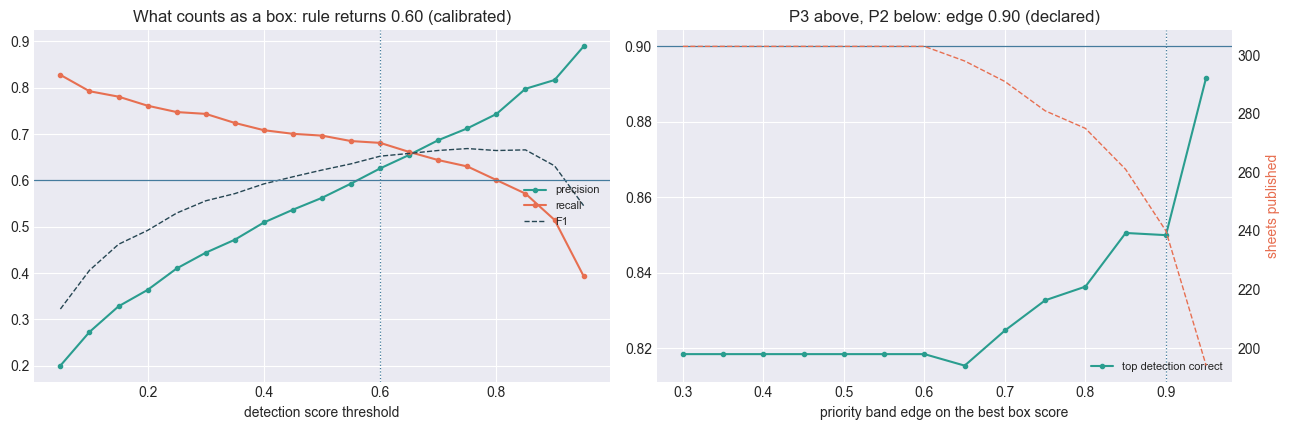

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(curve['threshold'], curve['precision'], marker='o', ms=3,
             color='#2a9d8f', label='precision')
axes[0].plot(curve['threshold'], curve['recall'], marker='o', ms=3,
             color='#e76f51', label='recall')
axes[0].plot(curve['threshold'], curve['f1'], color='#264653', lw=1, ls='--', label='F1')
axes[0].axhline(TARGET_PRECISION, color='#457b9d', lw=0.9)
axes[0].axvline(SCORE_THRESHOLD, color='#457b9d', lw=0.9, ls=':')
axes[0].set_xlabel('detection score threshold')
axes[0].set_title(f'What counts as a box: rule returns {SCORE_THRESHOLD:.2f} ({THRESHOLD_BASIS})')
axes[0].legend(loc='center right', fontsize=8)

axes[1].plot(band['edge'], band['top_correct'], marker='o', ms=3, color='#2a9d8f',
             label='top detection correct')
axes[1].axhline(TARGET_TOP_CORRECT, color='#457b9d', lw=0.9)
axes[1].axvline(BAND_EDGE, color='#457b9d', lw=0.9, ls=':')
second = axes[1].twinx()
second.plot(band['edge'], band['published'], color='#e76f51', lw=1, ls='--')
second.set_ylabel('sheets published', color='#e76f51')
second.grid(False)
axes[1].set_xlabel('priority band edge on the best box score')
axes[1].set_title(f'P3 above, P2 below: edge {BAND_EDGE:.2f} ({BAND_BASIS})')
axes[1].legend(loc='lower right', fontsize=8)
fig.tight_layout()
save_figure(fig, 'gc10_operating_points', subfolder=ASSETS)
plt.show()

## 10. The test split, scored once

Both operating points are now fixed on the selection split. They are applied
unchanged to the coils neither the fitting nor the choosing has seen.

In [16]:
test_predictions, test_truth, test_stems = predict(model, test_loader)
test_map, test_means, test_table = mean_average_precision(
    test_predictions, test_truth, (0.5, 0.75))
test_sheets = sheet_level(test_predictions, test_truth, SCORE_THRESHOLD)
test_precision, test_recall, test_tp, test_fp, test_positives = precision_recall_at(
    test_predictions, test_truth, SCORE_THRESHOLD)

print(f'test mAP@0.5   {test_means[0.5]:.4f}   (selection {selection_means[0.5]:.4f})')
print(f'test mAP@0.75  {test_means[0.75]:.4f}   (selection {selection_means[0.75]:.4f})')
print()
print(f'at the {SCORE_THRESHOLD:.2f} threshold: precision {test_precision:.4f}, '
      f'recall {test_recall:.4f}')
print(f'  {test_tp} boxes found of {test_positives}, {test_fp} claimed and not there')
published_test = test_sheets[test_sheets['detections'] > 0]
print(f'  {len(published_test)} of {len(test_sheets)} sheets carry at least one box '
      f'({len(published_test) / len(test_sheets):.1%}), so '
      f'{len(test_sheets) - len(published_test)} would publish no event')
print(f'  top detection correct on the published: {published_test["top_correct"].mean():.4f} '
      f'(selection {published["top_correct"].mean():.4f})')

test mAP@0.5   0.6260   (selection 0.6247)
test mAP@0.75  0.2129   (selection 0.2571)

at the 0.60 threshold: precision 0.6024, recall 0.6434
  350 boxes found of 544, 231 claimed and not there
  310 of 339 sheets carry at least one box (91.4%), so 29 would publish no event
  top detection correct on the published: 0.7710 (selection 0.8185)


In [17]:
test_per_class = test_table[test_table['iou'] == 0.5].copy()
test_per_class['class'] = test_per_class['class_id'].map(CLASS_NAMES)
selection_ap = selection_table[selection_table['iou'] == 0.5].set_index('class_id')['ap']
test_per_class['selection_ap'] = test_per_class['class_id'].map(selection_ap)
print(test_per_class[['class_id', 'class', 'ap', 'boxes', 'selection_ap']]
      .round(4).to_string(index=False))

 class_id         class     ap  boxes  selection_ap
        1 punching_hole 0.9478     61        1.0000
        2  welding_line 0.9487     87        0.9108
        3  crescent_gap 0.9988     49        0.7817
        4    water_spot 0.6568     41        0.8415
        5      oil_spot 0.6317     54        0.7206
        6     silk_spot 0.2676    167        0.3705
        7     inclusion 0.4461     39        0.1795
        8    rolled_pit 0.3684     14        0.2041
        9        crease 0.3388     11        0.5227
       10 waist_folding 0.6550     21        0.7155


  ✓ Saved → assets\cv\gc10_per_class_ap.png


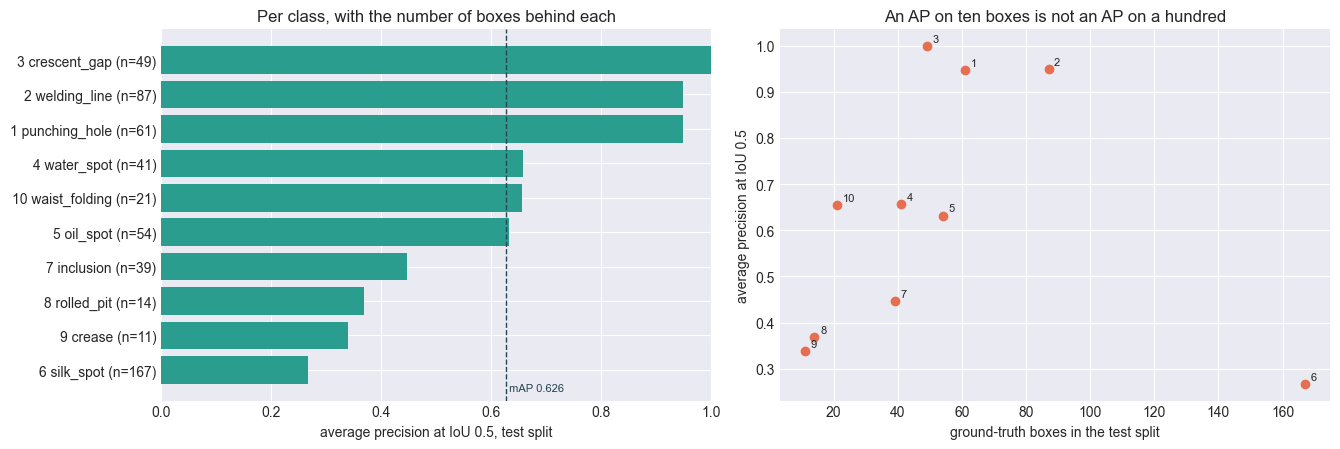

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
order = test_per_class.sort_values('ap')
axes[0].barh([f'{r.class_id} {r["class"]} (n={int(r.boxes)})' for _, r in order.iterrows()],
             order['ap'], color='#2a9d8f')
axes[0].axvline(test_means[0.5], color='#264653', ls='--', lw=1)
axes[0].text(test_means[0.5], -0.6, f' mAP {test_means[0.5]:.3f}', fontsize=8, color='#264653')
axes[0].set_xlabel('average precision at IoU 0.5, test split')
axes[0].set_xlim(0, 1)
axes[0].set_title('Per class, with the number of boxes behind each')

axes[1].scatter(test_per_class['boxes'], test_per_class['ap'], color='#e76f51', zorder=3)
for _, r in test_per_class.iterrows():
    axes[1].annotate(str(int(r['class_id'])), (r['boxes'], r['ap']),
                     textcoords='offset points', xytext=(4, 3), fontsize=8)
axes[1].set_xlabel('ground-truth boxes in the test split')
axes[1].set_ylabel('average precision at IoU 0.5')
axes[1].set_title('An AP on ten boxes is not an AP on a hundred')
fig.tight_layout()
save_figure(fig, 'gc10_per_class_ap', subfolder=ASSETS)
plt.show()

## 11. The frozen-backbone ablation

The same head on the same data with every backbone convolution frozen, so only the
region proposal network and the detection heads are fitted. It answers what the
COCO features are worth on rolled steel before any of them are adapted to it, and
it is the same ablation the casting and NEU modules ran, so the three computer
vision modules answer one question on one basis.

In [19]:
started = time.time()
frozen_model, frozen_history, frozen_best = train(
    freeze_backbone=True, seed=SEED, label='frozen ')
frozen_minutes = (time.time() - started) / 60
frozen_predictions, frozen_truth, _ = predict(frozen_model, test_loader)
_, frozen_means, frozen_table = mean_average_precision(
    frozen_predictions, frozen_truth, (0.5, 0.75))
print(f'\nfrozen arm: {frozen_minutes:.1f} min, best epoch {frozen_best} of {EPOCHS}')
print(f'test mAP@0.5  frozen {frozen_means[0.5]:.4f}  against fine-tuned {test_means[0.5]:.4f}  '
      f'({test_means[0.5] - frozen_means[0.5]:+.4f})')

  frozen epoch  1/10  loss 0.4004  selection mAP@0.5 0.3038  234s


  frozen epoch  2/10  loss 0.2706  selection mAP@0.5 0.4080  401s


  frozen epoch  3/10  loss 0.2579  selection mAP@0.5 0.4162  235s


  frozen epoch  4/10  loss 0.2520  selection mAP@0.5 0.4697  293s


  frozen epoch  5/10  loss 0.2452  selection mAP@0.5 0.4270  432s


...

  frozen epoch  7/10  loss 0.2354  selection mAP@0.5 0.5076  264s


  frozen epoch  8/10  loss 0.2335  selection mAP@0.5 0.4470  305s


  frozen epoch  9/10  loss 0.2236  selection mAP@0.5 0.4883  228s


  frozen epoch 10/10  loss 0.2176  selection mAP@0.5 0.5083  263s



frozen arm: 47.8 min, best epoch 10 of 10
test mAP@0.5  frozen 0.5175  against fine-tuned 0.6260  (+0.1085)


  ✓ Saved → assets\cv\gc10_training_curves.png


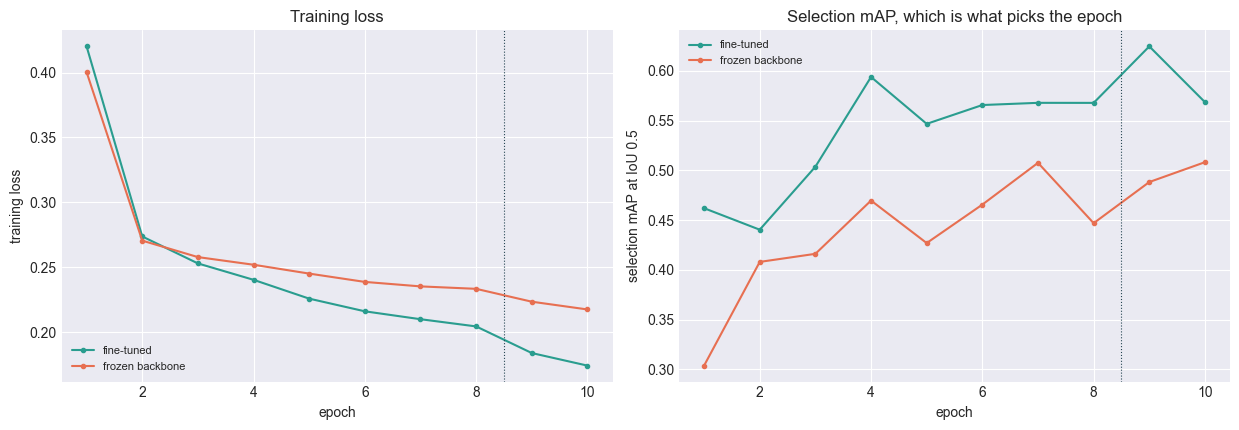

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for name, rows_, colour in (('fine-tuned', history, '#2a9d8f'),
                            ('frozen backbone', frozen_history, '#e76f51')):
    frame = pd.DataFrame(rows_)
    axes[0].plot(frame['epoch'], frame['train_loss'], marker='o', ms=3,
                 color=colour, label=name)
    axes[1].plot(frame['epoch'], frame['selection_map_50'], marker='o', ms=3,
                 color=colour, label=name)
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('training loss')
axes[0].set_title('Training loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('selection mAP at IoU 0.5')
axes[1].set_title('Selection mAP, which is what picks the epoch')
for ax in axes:
    ax.axvline(LR_DROP_EPOCH + 0.5, color='#264653', lw=0.8, ls=':')
    ax.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, 'gc10_training_curves', subfolder=ASSETS)
plt.show()

## 12. Does this reproduce

Casting's fine-tuned arm never returned the same numbers twice while its frozen
arm was bit-identical every time, which located the non-determinism in the
convolution backward pass rather than in the code. NEU refitted from the same seed
and moved its training loss in the fourth decimal while moving 0 of 360
predictions. This arm is asked the same question, and for a detector the answer
that matters operationally is whether the two thresholds and the published sheets
move, not whether a loss moves.

In [21]:
started = time.time()
repeat_model, repeat_history, repeat_best = train(freeze_backbone=False, seed=SEED,
                                                  label='repeat ')
repeat_minutes = (time.time() - started) / 60
repeat_selection, repeat_selection_truth, _ = predict(repeat_model, selection_loader)
repeat_test, repeat_test_truth, _ = predict(repeat_model, test_loader)
_, repeat_test_means, _ = mean_average_precision(repeat_test, repeat_test_truth, (0.5, 0.75))
print(f'\nrepeat arm: {repeat_minutes:.1f} min')

  repeat epoch  1/10  loss 0.4222  selection mAP@0.5 0.4665  635s


  repeat epoch  2/10  loss 0.2764  selection mAP@0.5 0.4765  1263s


  repeat epoch  3/10  loss 0.2544  selection mAP@0.5 0.5371  1246s


  repeat epoch  4/10  loss 0.2418  selection mAP@0.5 0.5575  1230s


  repeat epoch  5/10  loss 0.2339  selection mAP@0.5 0.5207  1229s


...

  repeat epoch  7/10  loss 0.2134  selection mAP@0.5 0.4968  308s


  repeat epoch  8/10  loss 0.2074  selection mAP@0.5 0.5298  317s


  repeat epoch  9/10  loss 0.1838  selection mAP@0.5 0.6255  436s


  repeat epoch 10/10  loss 0.1761  selection mAP@0.5 0.5565  639s



repeat arm: 133.7 min


In [22]:
# The same rules run again on the repeat, so the two thresholds are on one basis.
repeat_curve = pd.DataFrame([
    dict(zip(['threshold', 'precision', 'recall', 'tp', 'fp', 'positives'],
             (t,) + precision_recall_at(repeat_selection, repeat_selection_truth, t)))
    for t in grid])
repeat_curve['f1'] = 2 * repeat_curve['precision'] * repeat_curve['recall'] / (
    repeat_curve['precision'] + repeat_curve['recall']).replace(0, np.nan)
repeat_reaching = repeat_curve[repeat_curve['precision'] >= TARGET_PRECISION]
# The same rule with the same fallback, so a difference here is a difference of run
# and never a difference of rule.
repeat_threshold = (float(repeat_reaching['threshold'].min()) if not repeat_reaching.empty
                    else float(repeat_curve.loc[repeat_curve['f1'].idxmax(), 'threshold']))
repeat_sheets = sheet_level(repeat_test, repeat_test_truth, repeat_threshold)

comparison = pd.DataFrame([
    {'value': 'best epoch', 'run 1': best_epoch, 'run 2': repeat_best},
    {'value': 'final training loss', 'run 1': history[-1]['train_loss'],
     'run 2': repeat_history[-1]['train_loss']},
    {'value': 'selection mAP@0.5 at the best epoch',
     'run 1': round(max(r['selection_map_50'] for r in history), 5),
     'run 2': round(max(r['selection_map_50'] for r in repeat_history), 5)},
    {'value': 'test mAP@0.5', 'run 1': round(test_means[0.5], 5),
     'run 2': round(repeat_test_means[0.5], 5)},
    {'value': 'detection threshold the rule returns', 'run 1': SCORE_THRESHOLD,
     'run 2': repeat_threshold},
    {'value': 'test sheets that publish an event',
     'run 1': int((test_sheets['detections'] > 0).sum()),
     'run 2': int((repeat_sheets['detections'] > 0).sum())},
])
comparison['moved'] = comparison['run 1'] != comparison['run 2']
print(comparison.to_string(index=False))
print()
moved = int(comparison['moved'].sum())
print(f'{moved} of {len(comparison)} values moved between two runs of the same code at the '
      f'same seed.')
print('The last two rows are the operational ones: a training loss that moves in its fifth')
print('decimal costs nothing, while a threshold that moves changes which sheets reach a person.')

                               value     run 1     run 2  moved
                          best epoch   9.00000   9.00000  False
                 final training loss   0.17435   0.17609   True
 selection mAP@0.5 at the best epoch   0.62469   0.62546   True
                        test mAP@0.5   0.62598   0.64621   True
detection threshold the rule returns   0.60000   0.60000  False
   test sheets that publish an event 310.00000 306.00000   True

4 of 6 values moved between two runs of the same code at the same seed.
The last two rows are the operational ones: a training loss that moves in its fifth
decimal costs nothing, while a threshold that moves changes which sheets reach a person.


## 13. The priority bands the event adapter publishes

Every sheet in this dataset carries a defect, so like NEU this module has no good
class. Unlike NEU it can still decline to publish, because a detector that finds
nothing above its threshold has made no claim about the sheet. That is not the same
as calling the sheet sound, and the difference is the whole of the no-event rule.

In [23]:
def priority_for(best_score):
    """The best surviving box decides. The defect class never does."""
    if np.isnan(best_score):
        return None                                  # nothing found, so nothing published
    return 'P3' if best_score >= BAND_EDGE else 'P2'


test_sheets['priority'] = test_sheets['best_score'].apply(priority_for)
counts = test_sheets['priority'].value_counts(dropna=False)
print('what the adapter would publish from the test split:')
for priority in ('P2', 'P3'):
    n = int(counts.get(priority, 0))
    print(f'  {priority}: {n:4d} sheets ({n / len(test_sheets):.1%})')
print(f'  no event: {int(test_sheets["priority"].isna().sum()):4d} sheets '
      f'({test_sheets["priority"].isna().mean():.1%}), '
      f'because nothing scored above {SCORE_THRESHOLD:.2f}')
print()
print(f'P3, at or above {BAND_EDGE:.2f}: record the defect type against the coil and continue.')
print(f'P2, below it: the model found something and cannot name it with enough confidence,')
print('so a person looks before the coil is dispositioned.')
print('No P1: no single sheet on an inspection line is a fifteen-minute safety emergency,')
print('which is the same reasoning casting, NEU and MVTec each record.')
print('No P4: a sheet with nothing on it is not published at all, so there is no band for it.')
print()
print('And the honest reading of the no-event case, which section 6 of the model card carries:')
print('this module was fitted and scored only on sheets that contain a defect. It has never')
print('seen steel anyone certified sound, so "no detection" is a failure to find, not a pass.')

what the adapter would publish from the test split:
  P2:   63 sheets (18.6%)
  P3:  247 sheets (72.9%)
  no event:   29 sheets (8.6%), because nothing scored above 0.60

P3, at or above 0.90: record the defect type against the coil and continue.
P2, below it: the model found something and cannot name it with enough confidence,
so a person looks before the coil is dispositioned.
No P1: no single sheet on an inspection line is a fifteen-minute safety emergency,
which is the same reasoning casting, NEU and MVTec each record.
No P4: a sheet with nothing on it is not published at all, so there is no band for it.

And the honest reading of the no-event case, which section 6 of the model card carries:
this module was fitted and scored only on sheets that contain a defect. It has never
seen steel anyone certified sound, so "no detection" is a failure to find, not a pass.


showing 4 sheets: {'P3': 2, 'P2': 1, 'no event': 1}


  ✓ Saved → assets\cv\gc10_detections.png


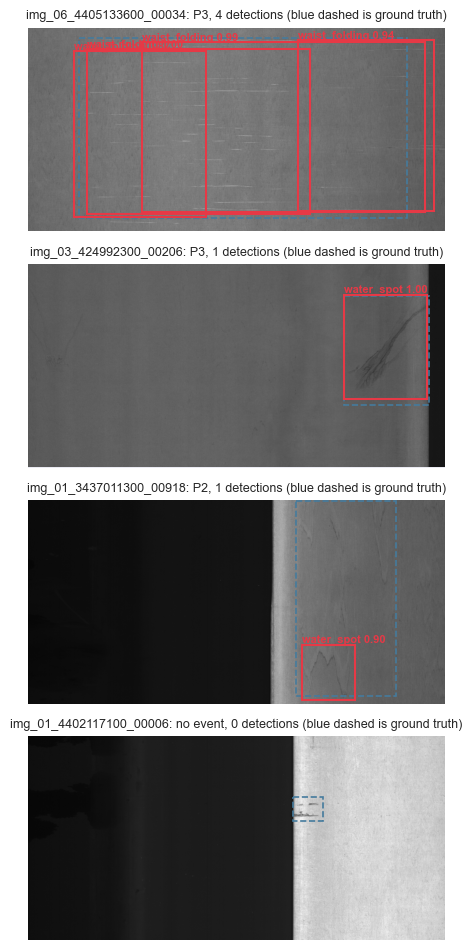

In [24]:
sample = test_sheets.copy()
sample['stem'] = test_stems
show = pd.concat([
    sample[sample['priority'] == 'P3'].nlargest(2, 'best_score'),
    sample[sample['priority'] == 'P2'].nlargest(1, 'best_score'),
    sample[sample['priority'].isna()].head(1)])
print(f'showing {len(show)} sheets: '
      f'{dict(Counter(row["priority"] or "no event" for _, row in show.iterrows()))}')
if show.empty:
    raise SystemExit('no sheets to draw, which cannot happen while the test split is non-empty')

fig, axes = plt.subplots(len(show), 1, figsize=(13, 2.4 * len(show)))
for ax, (position, row) in zip(np.atleast_1d(axes), show.iterrows()):
    index = list(sample.index).index(position)
    stem = test_stems[index]
    ax.imshow(np.asarray(Image.open(REPO_ROOT / sheets[stem]['image_path'])),
              cmap='gray', vmin=0, vmax=255)
    for box, label in zip(test_truth[index]['boxes'], test_truth[index]['labels']):
        ax.add_patch(Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                               fill=False, color='#457b9d', lw=1.2, ls='--'))
    keep = test_predictions[index]['scores'] >= SCORE_THRESHOLD
    for box, label, score in zip(test_predictions[index]['boxes'][keep],
                                 test_predictions[index]['labels'][keep],
                                 test_predictions[index]['scores'][keep]):
        ax.add_patch(Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1],
                               fill=False, color='#e63946', lw=1.5))
        ax.text(box[0], box[1] - 8, f'{CLASS_NAMES[int(label)]} {score:.2f}',
                color='#e63946', fontsize=8, weight='bold')
    ax.set_title(f'{stem}: {row["priority"] or "no event"}, {int(row["detections"])} detections '
                 f'(blue dashed is ground truth)', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
save_figure(fig, 'gc10_detections', subfolder=ASSETS)
plt.show()

## 14. Write the artifacts

Three files: the weights, the metrics file every downstream document cites, and
the prediction table the event adapter reads.

**The prediction table is JSON and not the `.npz` the other CV modules use.** A
detector returns a different number of boxes per sheet, so a rectangular array
would need padding or an object dtype, and an object dtype means the adapter has to
load with `allow_pickle=True`. Every other Arkon adapter loads with
`allow_pickle=False` on purpose. JSON keeps that property and stays readable.

In [25]:
PROC_DIR.mkdir(parents=True, exist_ok=True)
weights_path = MODEL_DIR / f'{MODEL_VERSION}.pt'
meta_path = MODEL_DIR / 'gc10_cv_meta.json'
predictions_path = PROC_DIR / 'test_gc10_predictions.json'

torch.save(model.state_dict(), weights_path)

meta = {
    'dataset': ('GC10-DET metallic surface defects, 2048 x 1000 single-channel photographs of '
                'steel sheet, ten defect classes with Pascal VOC boxes'),
    'architecture': 'fasterrcnn_resnet50_fpn_v2, COCO weights, eleven-way box head',
    'task': 'object detection',
    'min_size': MIN_SIZE,
    'max_size': MAX_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'best_epoch': best_epoch,
    'learning_rate': LEARNING_RATE,
    'lr_drop_epoch': LR_DROP_EPOCH,
    'warmup_iterations': WARMUP_ITERATIONS,
    'seed': SEED,
    'classes': {str(k): v for k, v in CLASS_NAMES.items()},
    'augmentation': ('horizontal and vertical flip only. A rotation is excluded because an '
                     'axis-aligned box cannot follow one: it either leaves the defect outside '
                     'the box or grows the box over background nobody marked.'),
    'split': {
        'unit': split_file['split_unit'],
        'note': split_file['split_unit_note'],
        'proportions': split_file['proportions'],
        'sheets': {name: len(subset) for name, subset in rows.items()},
        'boxes': {name: sum(len(r['boxes']) for r in subset) for name, subset in rows.items()},
        'coils': {name: len({r['source'] for r in subset}) for name, subset in rows.items()},
    },
    'label_repairs': split_file['repairs'],
    'metric': ('VOC 2010 all-point average precision, implemented in notebook 03 section 4 '
               'because neither torchmetrics nor pycocotools is in this environment, and '
               'validated there against six cases including two computed by hand'),
    'test_performance': {
        'measured_on': (f'{len(rows["test"])} sheets from '
                        f'{len({r["source"] for r in rows["test"]})} coils no other split '
                        f'contains, scored once'),
        'map_50': round(test_means[0.5], 5),
        'map_75': round(test_means[0.75], 5),
        'precision_at_threshold': round(test_precision, 5),
        'recall_at_threshold': round(test_recall, 5),
        'boxes_found': int(test_tp),
        'boxes_claimed_not_there': int(test_fp),
        'boxes_present': int(test_positives),
        'per_class_ap_50': {str(int(r['class_id'])): (None if np.isnan(r['ap'])
                                                      else round(float(r['ap']), 5))
                            for _, r in test_per_class.iterrows()},
        'per_class_boxes': {str(int(r['class_id'])): int(r['boxes'])
                            for _, r in test_per_class.iterrows()},
    },
    'selection_performance': {
        'map_50': round(selection_means[0.5], 5),
        'map_75': round(selection_means[0.75], 5),
    },
    'operating_point': {
        'detection_threshold': round(SCORE_THRESHOLD, 4),
        'detection_rule': (f'the lowest score at which precision over the selection split '
                           f'reaches {TARGET_PRECISION:.2f}'),
        'detection_rule_degenerated': bool(rule_degenerated),
        'threshold_basis': THRESHOLD_BASIS,
        'band_edge': round(BAND_EDGE, 4),
        'band_rule': (f'the lowest best-box score at which the top detection on a sheet is '
                      f'correct at IoU {IOU_MATCH} at least {TARGET_TOP_CORRECT:.0%} of the time '
                      f'on the selection split'),
        'band_rule_degenerated': bool(band_degenerated),
        'band_basis': BAND_BASIS,
        'iou_match': IOU_MATCH,
        'test_sheets_published': int((test_sheets['detections'] > 0).sum()),
        'test_sheets_silent': int((test_sheets['detections'] == 0).sum()),
        'test_top_detection_correct': round(float(published_test['top_correct'].mean()), 5),
    },
    'history': history,
    'ablation_frozen_backbone': {
        'best_epoch': frozen_best,
        'history': frozen_history,
        'test_map_50': round(frozen_means[0.5], 5),
        'test_map_75': round(frozen_means[0.75], 5),
        'minutes': round(frozen_minutes, 1),
    },
    'reproduction': {
        'note': 'the fine-tuned arm refitted from the same seed in the same session',
        'values_compared': int(len(comparison)),
        'values_moved': int(comparison['moved'].sum()),
        'run_2_best_epoch': int(repeat_best),
        'run_2_test_map_50': round(repeat_test_means[0.5], 5),
        'run_2_detection_threshold': (None if np.isnan(repeat_threshold)
                                      else round(repeat_threshold, 4)),
        'run_2_test_sheets_published': int((repeat_sheets['detections'] > 0).sum()),
    },
    'timing': {
        'fine_tuned_minutes': round(fine_tuned_minutes, 1),
        'device': torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'cpu',
        'input_scale_note': ('measured on this machine under sustained load: one training step '
                             'of two sheets costs 0.92 s at min_size 1000 / max_size 2048 and '
                             '0.32 s at 800 / 1600, which is 2.9 times the time for 1.6 times '
                             'the pixels. 800 is also the scale the COCO weights were fitted '
                             'at.'),
    },
}
meta_path.write_text(json.dumps(meta, indent=2), encoding='utf-8')

table = []
for index, stem in enumerate(test_stems):
    keep = test_predictions[index]['scores'] >= SCORE_THRESHOLD
    order = np.argsort(-test_predictions[index]['scores'][keep])
    table.append({
        'stem': stem,
        'image_path': sheets[stem]['image_path'],
        'source': sheets[stem]['source'],
        'image_size': [2048, 1000],
        'detections': [
            {'class_id': int(test_predictions[index]['labels'][keep][i]),
             'class_name': CLASS_NAMES[int(test_predictions[index]['labels'][keep][i])],
             'score': round(float(test_predictions[index]['scores'][keep][i]), 4),
             'box': [round(float(v), 1) for v in test_predictions[index]['boxes'][keep][i]]}
            for i in order],
        'truth': [{'class_id': int(label), 'class_name': CLASS_NAMES[int(label)],
                   'box': [round(float(v), 1) for v in box]}
                  for box, label in zip(test_truth[index]['boxes'],
                                        test_truth[index]['labels'])],
    })
predictions_path.write_text(json.dumps(
    {'model_version': MODEL_VERSION, 'detection_threshold': round(SCORE_THRESHOLD, 4),
     'band_edge': round(BAND_EDGE, 4), 'threshold_basis': THRESHOLD_BASIS,
     'band_basis': BAND_BASIS, 'classes': {str(k): v for k, v in CLASS_NAMES.items()},
     'sheets': table}, indent=1), encoding='utf-8')

for path in (weights_path, meta_path, predictions_path):
    print(f'wrote {path.relative_to(REPO_ROOT)}  ({path.stat().st_size / 2**20:.1f} MB)')
print()
print(f'the prediction table holds {len(table)} sheets and '
      f'{sum(len(row["detections"]) for row in table)} detections above the threshold')

wrote models\checkpoints\gc10\gc10_fasterrcnn_v1.pt  (165.6 MB)
wrote models\checkpoints\gc10\gc10_cv_meta.json  (0.0 MB)
wrote data\06_gc10\processed\test_gc10_predictions.json  (0.2 MB)

the prediction table holds 339 sheets and 581 detections above the threshold


## 15. Log the run

Into the same SQLite tracking store as the other five modules, under the experiment
name the README advertised before this module existed.

In [26]:
import mlflow

mlflow.set_tracking_uri(get_mlflow_uri())
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=MODEL_VERSION):
    mlflow.set_tags({'dataset': 'gc10_det', 'task': 'object_detection',
                     'framework': 'pytorch', 'architecture': 'fasterrcnn_resnet50_fpn_v2',
                     'num_classes': str(len(CLASS_NAMES)), 'department': 'Stamping',
                     'business_domain': 'visual_inspection'})
    mlflow.log_params({'min_size': MIN_SIZE, 'max_size': MAX_SIZE, 'batch_size': BATCH_SIZE,
                       'epochs': EPOCHS, 'learning_rate': LEARNING_RATE, 'seed': SEED,
                       'best_epoch': best_epoch, 'split_unit': split_file['split_unit'],
                       'target_precision': TARGET_PRECISION,
                       'target_top_correct': TARGET_TOP_CORRECT})
    mlflow.log_metrics({'test_map_50': float(test_means[0.5]),
                        'test_map_75': float(test_means[0.75]),
                        'test_precision': float(test_precision),
                        'test_recall': float(test_recall),
                        'detection_threshold': float(SCORE_THRESHOLD),
                        'band_edge': float(BAND_EDGE),
                        'frozen_test_map_50': float(frozen_means[0.5]),
                        'repeat_test_map_50': float(repeat_test_means[0.5])})
    for row in history:
        mlflow.log_metrics({'train_loss': row['train_loss'],
                            'selection_map_50': row['selection_map_50']}, step=row['epoch'])
    mlflow.log_artifact(str(meta_path))
    print(f'logged run {mlflow.active_run().info.run_id} to experiment {EXPERIMENT_NAME}')

logged run 15f1d36556d0403e9dc9720bee157c90 to experiment arkon-cv-gc10


## 16. Results

In [27]:
print(f'1. A ten-class detector over {len(rows["fit"]):,} sheets from '
      f'{len({r["source"] for r in rows["fit"]})} coils. On the {len(rows["test"])} test sheets, '
      f'from {len({r["source"] for r in rows["test"]})} coils no other split contains and scored '
      f'once: mAP@0.5 {test_means[0.5]:.4f}, mAP@0.75 {test_means[0.75]:.4f}.')
print(f'2. This is the first Arkon module that answers where. Casting, NEU and MVTec return one '
      f'answer per frame; this one returns {test_tp + test_fp} boxes over {len(rows["test"])} '
      f'sheets, {test_tp} of them on a real defect.')
print(f'3. Two operating points, not one. What counts as a box: '
      f'{SCORE_THRESHOLD:.2f} ({THRESHOLD_BASIS}), giving precision {test_precision:.4f} and '
      f'recall {test_recall:.4f} on test. How sure the sheet is: band edge {BAND_EDGE:.2f} '
      f'({BAND_BASIS}), above which the top detection is right '
      f'{published_test["top_correct"].mean():.1%} of the time.')
print(f'4. The metric is this notebook\'s own, because the environment has neither torchmetrics '
      f'nor pycocotools. It passes {passed} of {len(checks)} known cases including two computed '
      f'by hand, and nothing above would be valid if it did not.')
print(f'5. The frozen-backbone ablation reaches {frozen_means[0.5]:.4f} mAP@0.5 against '
      f'{test_means[0.5]:.4f} fine-tuned, a gap of {test_means[0.5] - frozen_means[0.5]:+.4f}. '
      f'That is what adapting COCO features to rolled steel is worth here.')
print(f'6. Refitting from the same seed moved {moved} of {len(comparison)} recorded values. '
      f'The two that matter operationally are the detection threshold and the count of sheets '
      f'that publish an event.')
print(f'7. The per-class spread is wide and the denominators explain most of it: '
      f'{", ".join(f"{int(r.class_id)} n={int(r.boxes)} AP={r.ap:.2f}" for _, r in test_per_class.nsmallest(3, "boxes").iterrows())}. '
      f'No per-class number in the model card appears without its box count.')
print(f'8. {int((test_sheets["detections"] == 0).sum())} of {len(test_sheets)} test sheets carry '
      f'no box above the threshold and would publish no event. That is the module failing to '
      f'find a defect that is there, not the module passing the sheet: every sheet it has ever '
      f'seen, in fitting and in scoring, contains one.')

1. A ten-class detector over 1,619 sheets from 289 coils. On the 339 test sheets, from 83 coils no other split contains and scored once: mAP@0.5 0.6260, mAP@0.75 0.2129.
2. This is the first Arkon module that answers where. Casting, NEU and MVTec return one answer per frame; this one returns 581 boxes over 339 sheets, 350 of them on a real defect.
3. Two operating points, not one. What counts as a box: 0.60 (calibrated), giving precision 0.6024 and recall 0.6434 on test. How sure the sheet is: band edge 0.90 (declared), above which the top detection is right 77.1% of the time.
4. The metric is this notebook's own, because the environment has neither torchmetrics nor pycocotools. It passes 7 of 7 known cases including two computed by hand, and nothing above would be valid if it did not.
5. The frozen-backbone ablation reaches 0.5175 mAP@0.5 against 0.6260 fine-tuned, a gap of +0.1085. That is what adapting COCO features to rolled steel is worth here.
6. Refitting from the same seed move